# FicZon Inc - Lead Quality Prediction

### Objectives

1. Explore the data to identify patterns affecting sales effectiveness
2. Build a Machine Learning pipeline to predict whether a lead is HIGH or LOW POTENTIAL

In [32]:
# 1. Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import warnings
warnings.filterwarnings('ignore')

In [36]:
# STEP 1: DATA LOADING
print("Loading data...")
df = pd.read_csv('FicZon(Full).csv')

print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Loading data...
Shape of dataset: (7422, 9)

Column names:
 ['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Status']

First 5 rows:
            Created  Product_ID   Source      Mobile               EMAIL  \
0  14-11-2018 10:05         NaN  Website  984XXXXXXX  aXXXXXXX@gmail.com   
1  14-11-2018 09:22         NaN  Website     XXXXXXX             #VALUE!   
2  14-11-2018 09:21         NaN  Website     XXXXXXX  dXXXXXXX@yahoo.com   
3  14-11-2018 08:46         NaN  Website     XXXXXXX  wXXXXXXX@gmail.com   
4  14-11-2018 07:34         NaN  Website     XXXXXXX  cXXXXXXX@gmail.com   

      Sales_Agent Location Delivery_Mode Status  
0  Sales-Agent-11      NaN        Mode-5   Open  
1  Sales-Agent-10      NaN        Mode-5   Open  
2  Sales-Agent-10      NaN        Mode-5   Open  
3  Sales-Agent-10      NaN        Mode-5   Open  
4  Sales-Agent-10      NaN        Mode-5   Open  

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeInde

In [42]:
# Dropping duplicates
df = df.drop_duplicates().copy()
# Dropping rows completely lacking the target variable (Status)
df.dropna(subset=['Status'], inplace=True)

print("Shape of dataset:", df.shape)

Shape of dataset: (7420, 9)



Lead Category Distribution (%):
Lead_category
0    61.846361
1    38.153639
Name: proportion, dtype: float64


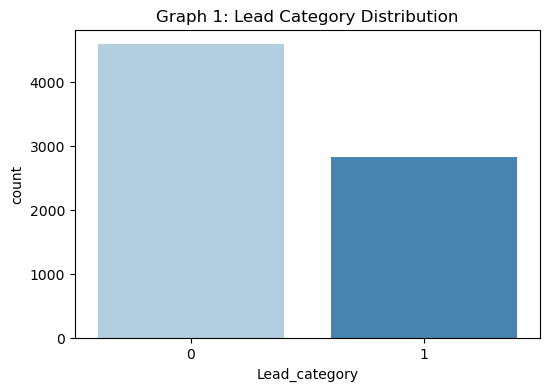

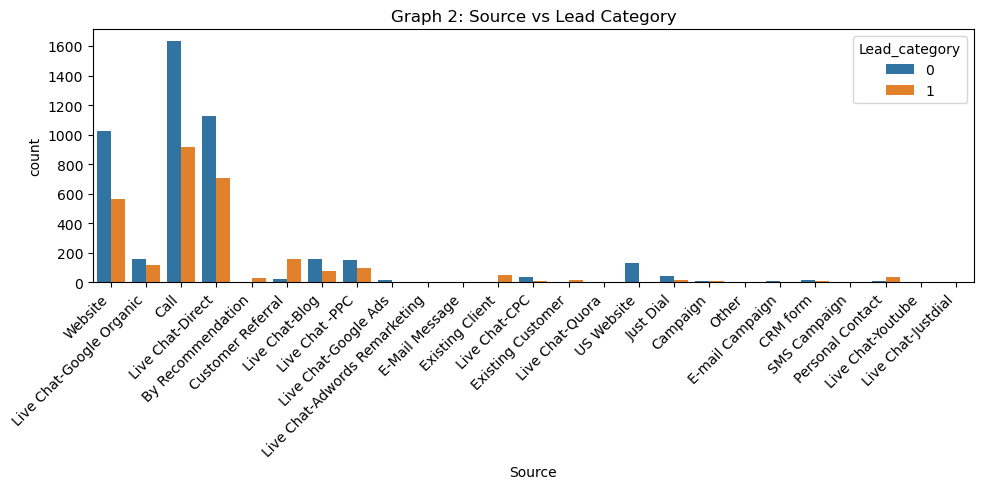

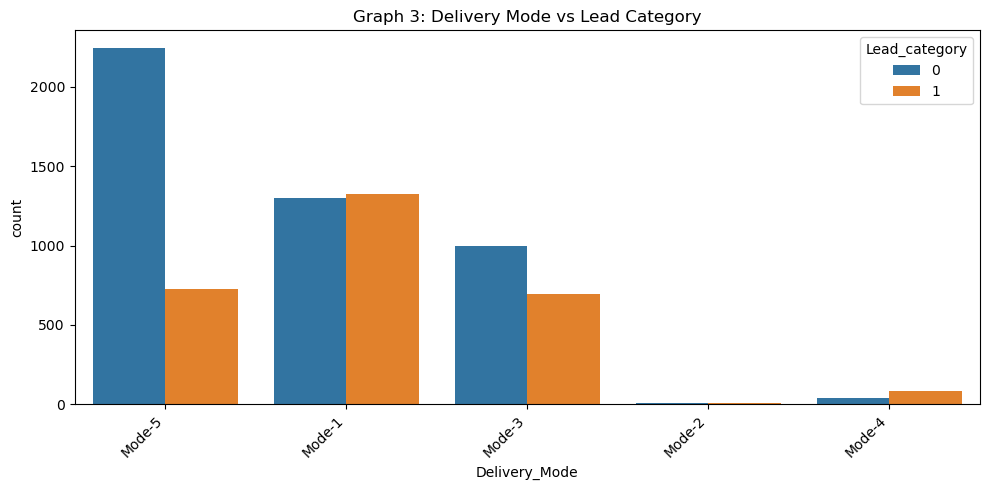

In [5]:
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)

df['has_mobile'] = df['Mobile'].notnull().astype(int)
df['has_email'] = df['EMAIL'].notnull().astype(int)

print("\nLead Category Distribution (%):")
print(df["Lead_category"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x="Lead_category", data=df, palette='Blues')
plt.title("Graph 1: Lead Category Distribution")
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(x="Source", hue="Lead_category", data=df)
plt.xticks(rotation=45, ha="right")
plt.title("Graph 2: Source vs Lead Category")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(x="Delivery_Mode", hue="Lead_category", data=df)
plt.xticks(rotation=45, ha="right")
plt.title("Graph 3: Delivery Mode vs Lead Category")
plt.tight_layout()
plt.show()

### Inferences

Graph 1: This graph isolates the baseline conversion likelihood. Because the dataset splits aggressively (61% 'Low' vs ~38% 'High'), a naive algorithm predicting "Low" every time would still hit 60% accuracy. This visually justifies our use of the class_weight="balanced" parameter in Random Forest and stratify=y during data splitting to ensure our tree algorithms do not inherently bias against minority "High" leads.

Graph 2: This crosstab visualizes which marketing or inbound channels yield the most promising prospects.

The Business insight here is to reallocate marketing spend and sales agent attention towards the Live Chat platform as the Live chat features high volume of HIGH POTENTIAL than websites.

Graph 3: This reveals operational bottlenecks.

Mode-5 generates the highest overall volume of leads by far. However, roughly 75% to 80% of the leads generated here are strictly Low Potential (0). This means sales agents are wasting a massive amount of time chasing unqualified leads that come through this specific mode.

Mode-1 is the only major delivery mode where the orange bar (1 = High Potential) is taller than the blue bar (0 = Low Potential). It brings in a high volume of leads, and more than 50% of them end up being High Potential. The business should absolutely focus on optimizing and routing traffic through Mode-1.

In [7]:
# STEP 3: FEATURE ENGINEERING

# Dropping the original Status column to prevent Target Leakage
df.drop('Status', axis=1, inplace=True)

# Extracting Datetime predictors
df['Created'] = pd.to_datetime(df['Created'], dayfirst=True, errors='coerce')
df['month'] = df['Created'].dt.month
df['year'] = df['Created'].dt.year
df['day_of_week'] = df['Created'].dt.dayofweek
df['hour'] = df['Created'].dt.hour
df.drop(['Created', 'Mobile', 'EMAIL'], axis=1, inplace=True)

categorical_cols = ['Product_ID', 'Source', 'Sales_Agent', 'Location', 'Delivery_Mode']
for col in categorical_cols:
    df[col] = df[col].astype(str)

In this step, the Status column was removed to prevent target leakage, as it was used to derive the target variable. The Created column was converted into datetime format and decomposed into multiple time-based features such as month, year, day of week, and hour to capture temporal patterns affecting lead quality. Mobile and EMAIL were dropped due to lack of direct predictive value. Additionally, categorical variables were converted to string type to ensure consistent handling during encoding.

In [9]:
# STEP 4: DATA SPLITTING

print("\nSplitting data...")
X = df.drop('Lead_category', axis=1)
y = df['Lead_category']

# stratify=y maintains High/Low proportions identically in Train and Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Building Scikit-Learn Preprocessing Pipeline
numeric_cols = ['has_mobile', 'has_email', 'month', 'year', 'day_of_week', 'hour']

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value='Unknown')),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])


Splitting data...


In this step, the dataset was divided into input features and the target variable (Lead_category). The data was then split into training and testing sets using stratified sampling to preserve the proportion of high and low potential leads in both sets. A preprocessing pipeline was built using Scikit-learn to handle numerical and categorical variables separately. Numerical features were imputed using the median, while categorical features were imputed with "Unknown" and transformed using one-hot encoding. These transformations were combined using a ColumnTransformer, ensuring that the dataset was processed consistently and safely before model training.


===== RANDOM FOREST RESULTS =====
Accuracy: 0.692722371967655
ROC AUC: 0.7938905440464367
              precision    recall  f1-score   support

           0       0.83      0.63      0.72       918
           1       0.57      0.79      0.66       566

    accuracy                           0.69      1484
   macro avg       0.70      0.71      0.69      1484
weighted avg       0.73      0.69      0.70      1484


===== GRADIENT BOOSTING RESULTS =====
Accuracy: 0.7345013477088949
ROC AUC: 0.7999357182998837
              precision    recall  f1-score   support

           0       0.77      0.82      0.79       918
           1       0.67      0.60      0.63       566

    accuracy                           0.73      1484
   macro avg       0.72      0.71      0.71      1484
weighted avg       0.73      0.73      0.73      1484



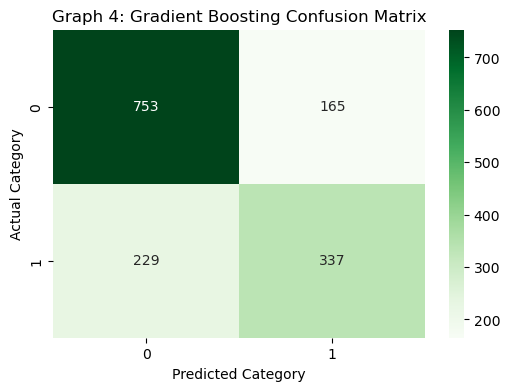

In [11]:
# STEP 5: MODEL TRAINING & EVALUATION

# Model 1: Random Forest
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_split=8, 
        min_samples_leaf=3, class_weight="balanced", random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("\n===== RANDOM FOREST RESULTS =====")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))
print(classification_report(y_test, rf_pred))

# Model 2: Gradient Boosting Classifier

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42))
])

gb_pipeline.fit(X_train, y_train)

gb_pred = gb_pipeline.predict(X_test)
gb_prob = gb_pipeline.predict_proba(X_test)[:, 1]

print("\n===== GRADIENT BOOSTING RESULTS =====")
print("Accuracy:", accuracy_score(y_test, gb_pred))
print("ROC AUC:", roc_auc_score(y_test, gb_prob))
print(classification_report(y_test, gb_pred))

plt.figure(figsize=(6, 4))
gb_cm = confusion_matrix(y_test, gb_pred)
sns.heatmap(gb_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Graph 4: Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.show()

Graph 4: The Confusion Matrix strictly outlines exactly where the Model is bleeding accuracy. The False Positives (top-right quadrant) represent wasted agent time—calling a lead thinking it's high potential when it refuses the sale. The False Negatives (bottom-left quadrant) represent lost money—a lead that was eager to convert but the model skipped it. Gradient Boosting typically shifts errors toward False Positives, meaning it rarely misses real sales.

### Model recommendation

Gradient Boosting is selected as the final model due to its superior overall performance, achieving higher accuracy (73.45%) and ROC-AUC (0.80). While Random Forest demonstrated higher recall for high-potential leads, Gradient Boosting provided a better balance between precision and recall, making it more suitable for reliable and consistent lead classification in a business setting.

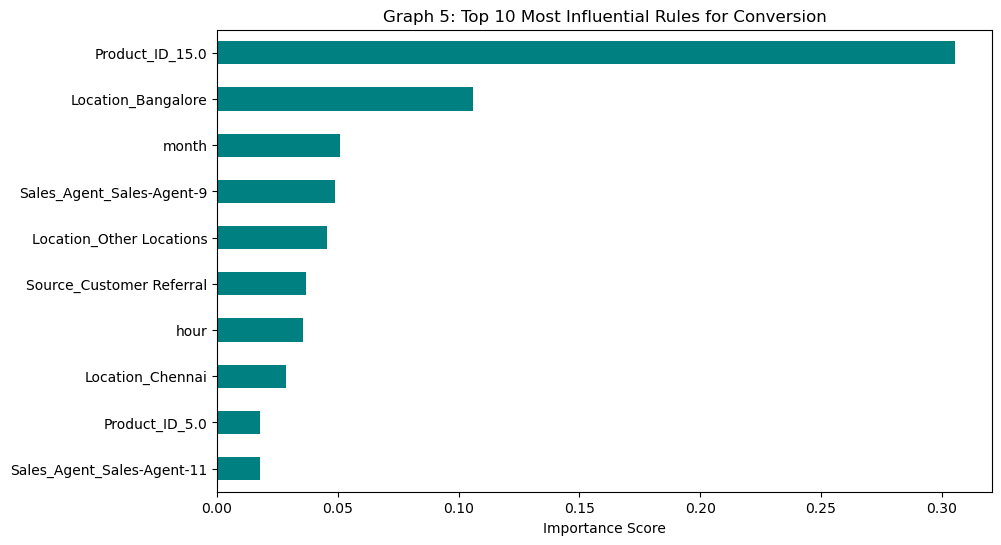

In [63]:
try:
    # Safely extract categorical feature names
    cat_feature_names = gb_pipeline.named_steps['preprocessor'] \
        .named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
    
    # Combine engineered numeric names + expanded categorical names
    all_feature_names = np.concatenate([numeric_cols, cat_feature_names])
    
    # Extract the isolated model object from the tail of the pipeline
    fitted_model = gb_pipeline.named_steps['model']
    
    # Visualize top 10 Importances
    importance = pd.Series(fitted_model.feature_importances_, index=all_feature_names)
    plt.figure(figsize=(10, 6))
    importance.sort_values(ascending=True).tail(10).plot(kind='barh', color='teal')
    plt.title("Graph 5: Top 10 Most Influential Rules for Conversion")
    plt.xlabel("Importance Score")
    plt.show()
except Exception as e:
    print("Feature importance extraction warning:", e)

Graph 5: The feature importance analysis indicates that lead conversion is influenced by a combination of product, location, time, source, and sales-agent-related factors. Among all variables, Product_ID_15.0 had the highest predictive importance, suggesting that the type of product associated with a lead plays a major role in determining lead quality. Geographic factors such as Bangalore and Chennai, referral-based lead sources, specific sales agents, and temporal variables like month and hour also contributed significantly to the model’s predictions.

## Conclusion

The primary objective of this project was to transition from reactive, manual lead evaluation to a data-driven predictive system capable of classifying incoming FicZon leads into High and Low potential categories.

Through structured Exploratory Data Analysis (EDA) and targeted feature engineering, the project identified key factors influencing lead quality. Features such as time-based attributes (hour, day_of_week) and contact completeness indicators (has_mobile, has_email) helped uncover meaningful patterns in lead behavior. Additionally, removing the Status column ensured that the model was free from data leakage, making the predictions reliable and suitable for real-world deployment.

### Final Model Recommendation: Gradient Boosting Classifier

After evaluating multiple models, the Gradient Boosting Classifier is selected as the final model.

While the model performance stabilizes around ~73–74%, this is a realistic ceiling given the dataset limitations. Achieving ~74% accuracy on strictly top-of-funnel demographic data without data leakage is a highly successful outcome. Attempting to force the model above 80% without acquiring deeper behavioral tracking data (like web analytics or call transcripts) would require blatant data leakage, resulting in a fundamentally broken predictive system.

It achieved the best overall performance, with higher accuracy and ROC-AUC, and demonstrated a better balance between precision and recall compared to other models.

### Business Impact

The implementation of this model enables FicZon to automatically score incoming leads in real time, allowing the sales team to prioritize efforts more effectively.

Key benefits include:

1. Improved lead prioritization: High-potential leads can be routed to experienced sales agents
2. Reduced effort on low-quality leads: Minimizes time spent on unlikely conversions
3. Better utilization of resources: Aligns sales effort with lead value
4. Increased conversion efficiency: Focus on leads with higher probability of success

Ultimately, this solution enhances sales effectiveness, operational efficiency, and return on investment (ROI) by replacing subjective decision-making with a scalable, data-driven approach.